In [16]:
import torch 
import torchvision
from torchvision import transforms, datasets

train = datasets.MNIST('', train=True, download=True, transform=transforms.Compose([transforms.ToTensor()]))
test = datasets.MNIST('', train=False, download=True, transform=transforms.Compose([transforms.ToTensor()]))

trainset = torch.utils.data.DataLoader(train, batch_size=10, shuffle=True)
testset = torch.utils.data.DataLoader(test, batch_size=10, shuffle=False)



In [17]:
import torch.nn as nn
import torch.nn.functional as F


In [18]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(28*28, 64)  # 64 (hidden layer) output features, 28*28 is inpurt layer
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)  
        self.fc4 = nn.Linear(64, 10)  #10 classes 0 to 9

    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        x=self.fc4(x)

        return F.log_softmax(x, dim=1)
        

net = Net()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [19]:
# import torch

X = torch.rand((28,28))
X=X.view(-1, 28,28)
# X_flat reshapes the tensor X from shape (1, 28, 28) to (1, 784), flattening the 28x28 image into a single vector.
# This is necessary because the neural network expects input of shape (batch_size, 784).
X_flat = X.view(-1, 28*28)
output = net(X_flat)
output

tensor([[-2.3006, -2.4325, -2.3143, -2.3729, -2.2542, -2.3153, -2.2364, -2.2752,
         -2.2501, -2.2903]], grad_fn=<LogSoftmaxBackward0>)

In [ ]:
import torch.optim as optim

optimizer = optim.Adam(net.parameters(), lr=0.001)  

EPOCHS = 3
for epoch in range(EPOCHS):
    for data in trainset:
        X, y = data
        net.zero_grad()
        
       # Flatten the images
        X = X.view(-1, 28*28)
        # Zero the gradients
        optimizer.zero_grad()
        # Forward pass
        output = net(X)
        # Calculate loss
        loss = F.nll_loss(output, y)
        # Backward pass
        loss.backward()
        # Update weights
        optimizer.step()
    print(f"Epoch {epoch+1} complete. Loss: {loss.item()}")

Epoch 1 complete. Loss: 0.002529360819607973
Epoch 2 complete. Loss: 0.2947755455970764
Epoch 3 complete. Loss: 0.043171562254428864


In [23]:
correct = 0
total = 0 
with torch.no_grad():
    for data in trainset:
        X,y = data
        output=net(X.view(-1,784))
        for idx, i in enumerate(output):
            if torch.argmax(i)==y[idx]:
                correct+=1
            total+=1
print("accuracy: ", round(correct/total, 3))

accuracy:  0.988


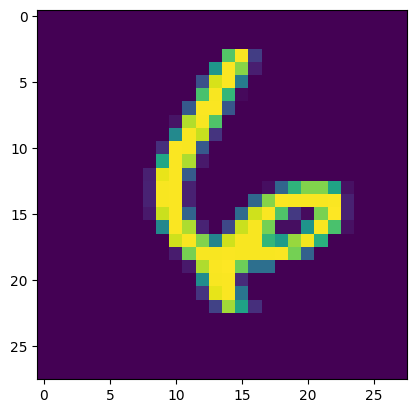

In [26]:
import matplotlib.pyplot as plt
plt.imshow(X[0].view(28,28))
plt.show()

In [27]:
print(torch.argmax(net(X[0].view(-1, 784))[0]))


tensor(6)
